In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
df = pd.read_csv("student_pass_fail_final.csv")

In [5]:
df.head()

,Study_Hours,Sleeping_Hours,Social_Media_Usage,Playing_Hours,Previous_Score,Attendance,Pass
0,4.370861,7.852190,0.515619,4.571494,44.0,51.0,0
1,9.556429,4.504840,4.512765,0.588755,57.0,69.0,1
2,7.587945,4.969772,2.526262,2.882582,67.0,50.0,1
3,6.387926,9.391325,4.132287,1.370276,81.0,86.0,1
4,2.404168,7.638574,NaN,2.770890,61.0,58.0,0


In [7]:
df.sample(5)

,Study_Hours,Sleeping_Hours,Social_Media_Usage,Playing_Hours,Previous_Score,Attendance,Pass
185,6.939856,8.820886,1.200728,4.310638,52.0,51.0,1
155,3.178497,7.854516,2.017414,3.038684,77.0,78.0,1
43,9.183884,6.220952,1.853211,1.671219,65.0,74.0,1
65,5.884265,8.444612,1.874353,4.364729,97.0,89.0,1
113,8.273083,9.775890,4.330319,4.373508,98.0,80.0,1


In [8]:
df.shape

(210, 7)

In [9]:
df.info

<bound method DataFrame.info of      Study_Hours  Sleeping_Hours  ...  Attendance  Pass
0       4.370861        7.852190  ...        51.0     0
1       9.556429        4.504840  ...        69.0     1
2       7.587945        4.969772  ...        50.0     1
3       6.387926        9.391325  ...        86.0     1
4       2.404168        7.638574  ...        58.0     0
..           ...             ...  ...         ...   ...
205     8.843145        8.175845  ...        85.0     1
206     9.881982        5.761551  ...        55.0     1
207          NaN        4.604668  ...         NaN     0
208     6.806555        4.427132  ...        96.0     1
209     6.962701        9.569911  ...        91.0     1

[210 rows x 7 columns]>

In [11]:
df.isnull().sum()

Study_Hours           6
Sleeping_Hours        5
Social_Media_Usage    5
Playing_Hours         5
Previous_Score        5
Attendance            6
Pass                  0
dtype: int64

In [12]:
df.fillna(df.mean(), inplace=True)

,Study_Hours,Sleeping_Hours,Social_Media_Usage,Playing_Hours,Previous_Score,Attendance,Pass
0,4.370861,7.852190,0.515619,4.571494,44.0,51.000000,0
1,9.556429,4.504840,4.512765,0.588755,57.0,69.000000,1
2,7.587945,4.969772,2.526262,2.882582,67.0,50.000000,1
3,6.387926,9.391325,4.132287,1.370276,81.0,86.000000,1
4,2.404168,7.638574,2.610868,2.770890,61.0,58.000000,0
...,...,...,...,...,...,...,...
205,8.843145,8.175845,0.131835,4.695338,45.0,85.000000,1
206,9.881982,5.761551,4.816113,3.461383,54.0,55.000000,1
207,5.361662,4.604668,2.569947,3.791192,43.0,74.367647,0
208,6.806555,4.427132,4.311819,1.122203,59.0,96.000000,1


In [15]:
print("\nDuplicated Rows: ", df.duplicated().sum())


Duplicated Rows:  10


In [16]:
df.drop_duplicates(inplace=True)

In [39]:
df.shape

(200, 7)

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Study_Hours         200 non-null    float64
 1   Sleeping_Hours      200 non-null    float64
 2   Social_Media_Usage  200 non-null    float64
 3   Playing_Hours       200 non-null    float64
 4   Previous_Score      200 non-null    float64
 5   Attendance          200 non-null    float64
 6   Pass                200 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 11.1 KB


In [21]:
# Features & Target Variable
X = df.drop(columns=["Pass"]) # Features
Y = df["Pass"] # Target Variable

In [ ]:
# Split the dataset into training and testing sets and store them in separate variables
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state=42)

In [ ]:
# Feature Scaling
# Why scale? -> To ensure all features contribute equally to the model
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
# Logistic Regression Model Building and Train the Model
model = LogisticRegression()
model.fit(X_train, Y_train) # Qsn and Ans analogy

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [25]:
# Predictions
y_pred = model.predict(X_test)

In [26]:
y_pred

array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [28]:
print(np.array(Y_test))

[1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1]


In [29]:
# Model Evaluation
accuracy = accuracy_score(Y_test, y_pred)
accuracy

0.975

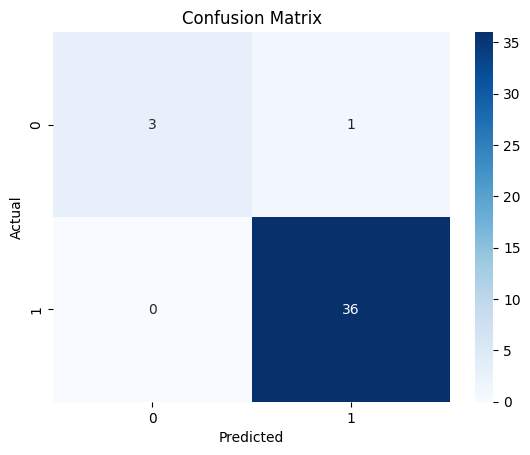

In [34]:
# Confusion Matrix
conf_matrix = confusion_matrix(Y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
# Classification Report
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86         4
           1       0.97      1.00      0.99        36

    accuracy                           0.97        40
   macro avg       0.99      0.88      0.92        40
weighted avg       0.98      0.97      0.97        40



In [47]:
# Function to predict pass/fail based on User Input
def predict_student_performance():
    print("Enter student details for prediction: ")
    study_hours = float(input("Study Hours (1-10): "))
    sleeping_hours = float(input("Sleeping Hours (4-10): "))
    social_media_usage = float(input("Social Media Usage (0-5): "))
    playing_hours = float(input("Playing Hours (0-5): "))
    previous_score = float(input("Previous Score (40-100): "))
    attendance = float(input("Attendance (50-100%): "))

    # Dataframe for user input
    user_data = pd.DataFrame([[
        study_hours,
        sleeping_hours,
        social_media_usage,
        playing_hours,
        previous_score,
        attendance
    ]], columns=X.columns)

    # Scale the user input data
    user_data_scaled = scaler.transform(user_data)

    # Predict Result
    prediction = model.predict(user_data_scaled)[0]

    # Output Result
    result = "Pass" if prediction == 1 else "Fail"
    print(f"The student is likely to {result}")

predict_student_performance()

Enter student details for prediction: 
The student is likely to Pass


C:\Users\nayan\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
